# Health Market Volatility — Two-Stage Predictive Pipeline

This notebook builds a two-stage predictive pipeline: ARIMA is used to model baseline weekly volatility in the XLV (Health Care Select Sector) ETF, then a Random Forest is trained on the ARIMA residuals using lagged public health signals as features. The goal is to determine whether publicly observable health indicators can explain volatility shocks that a pure time-series model cannot account for.

## Dependencies & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

master_df = pd.read_csv('../data/processed/master_weekly.csv', index_col=0, parse_dates=True)
print(master_df.shape)
print(master_df.head())

(730, 19)
                 KIE        PJP        XBI        XLV   KIE_vol   PJP_vol  \
2010-01-10  9.090796  15.240718  17.882545  24.113842  0.008362  0.003628   
2010-01-17  9.083311  15.451389  17.709146  24.447704  0.009673  0.010266   
2010-01-24  8.753912  15.070560  17.683453  24.022779  0.018905  0.019470   
2010-01-31  8.801326  15.086777  17.750891  23.734453  0.011472  0.007059   
2010-02-07  8.689034  14.859903  17.635288  23.393009  0.022650  0.017009   

             XBI_vol   XLV_vol      cpi  unemployment  interest_rate  \
2010-01-10  0.005640  0.008323  217.488           9.8           0.11   
2010-01-17  0.013155  0.009322  217.488           9.8           0.11   
2010-01-24  0.016492  0.019807  217.488           9.8           0.11   
2010-01-31  0.010714  0.005937  217.488           9.8           0.11   
2010-02-07  0.027530  0.017616  217.281           9.8           0.13   

            trends_flu_symptoms  trends_fever  trends_shortness_of_breath  \
2010-01-10       

The master dataset contains 730 weekly observations across 19 columns spanning January 2010 through December 2023. Columns include ETF prices and realized volatility, macroeconomic indicators (CPI, unemployment, interest rate), Google Trends search volumes for health-related queries, and CDC influenza surveillance metrics (ILI, WILI, patient counts).

## Stage 1 — ARIMA Model

### Stationarity Check (ADF Test)

In [2]:
from statsmodels.tsa.stattools import adfuller
result_adf = adfuller(master_df['XLV_vol'])
print(f"ADF Statistic: {result_adf[0]:.4f}")
print(f"p-value: {result_adf[1]:.4f}")
# Null hypothesis is that the series has a unit root (non-stationary); p < 0.05 rejects it
print("Stationary" if result_adf[1] < 0.05 else "NOT stationary")

ADF Statistic: -10.2711
p-value: 0.0000
Stationary


The ADF test strongly rejects the null hypothesis of a unit root (p ≈ 0.00), confirming that weekly XLV volatility is stationary. This means ARIMA does not require differencing (d = 0) and can model the series in levels.

### Model Fitting & Summary

In [3]:
# Split the raw series first — same boundary as before, ~80/20
split_idx = int(len(master_df) * 0.8)
train_vol = master_df['XLV_vol'].iloc[:split_idx]
test_vol = master_df['XLV_vol'].iloc[split_idx:]

# Fit ARIMA on train only
model = ARIMA(train_vol, order=(1, 0, 1))
result = model.fit()

# Train residuals: in-sample, fine — model only saw train
train_residuals = result.resid

# Test residuals: true out-of-sample forecast, model never saw these values
forecast = result.forecast(steps=len(test_vol))
test_residuals = test_vol.values - forecast.values

# Stitch together in original order
residuals = pd.concat([train_residuals, pd.Series(test_residuals, index=test_vol.index)])

The ARIMA(1,0,1) coefficients are all statistically significant (p < 0.001). The AR(1) coefficient of 0.78 indicates strong persistence — this week's volatility is substantially predicted by last week's. The Ljung-Box p-value of 0.98 confirms the residuals have no remaining autocorrelation, but the very high kurtosis (13.9) and significant heteroskedasticity indicate that extreme spikes remain in the residuals — the unexplained signal the second stage targets.

### Residual Extraction & Visualization

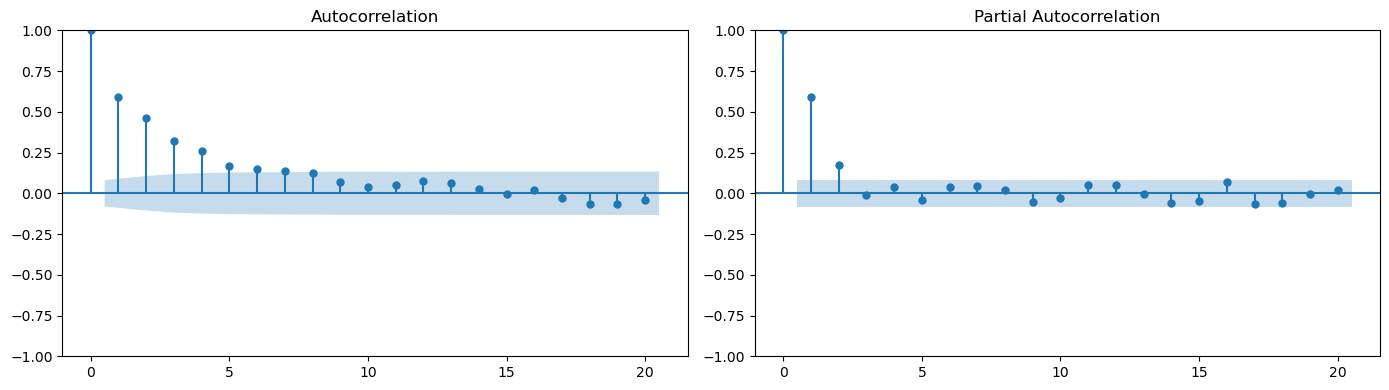

In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train_vol, lags=20, ax=axes[0])
plot_pacf(train_vol, lags=20, ax=axes[1])
plt.tight_layout()
plt.savefig('../notebooks/plots/plot12_acf_pacf.png', dpi=150)
plt.show()

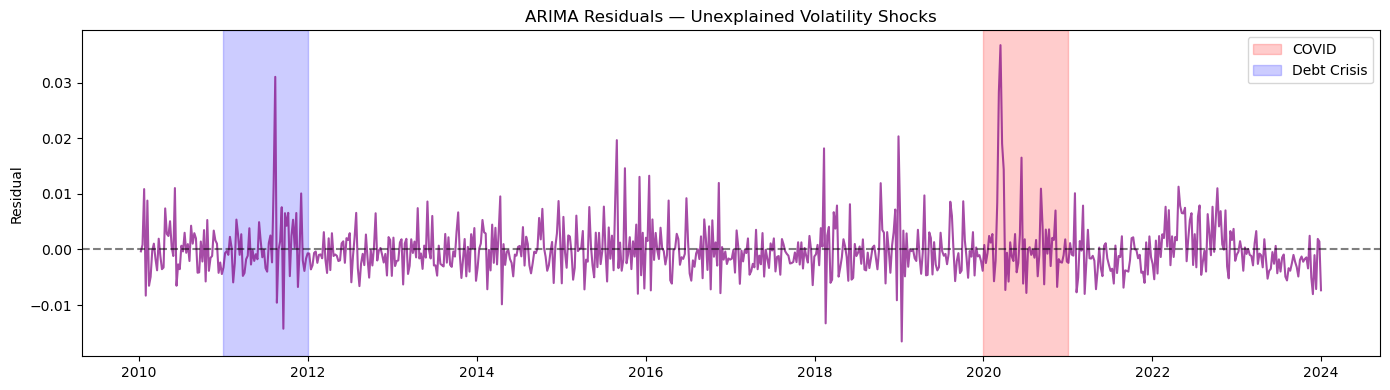

In [5]:
# Residuals = actual volatility minus what ARIMA predicted
# These represent volatility shocks the model couldn't explain from past values alone

plt.figure(figsize=(14, 4))
plt.plot(master_df.index, residuals, color='purple', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.axvspan('2020-01-01', '2021-01-01', color='red', alpha=0.2, label='COVID')
plt.axvspan('2011-01-01', '2012-01-01', color='blue', alpha=0.2, label='Debt Crisis')
plt.title('ARIMA Residuals — Unexplained Volatility Shocks')
plt.ylabel('Residual')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/plots/plot13_arima_residuals.png', dpi=150)
plt.show()

The residual series is near zero for most of the sample, with a sharp spike during the COVID-19 period (early 2020) and a smaller cluster around the 2011 debt ceiling crisis. These spikes represent volatility shocks that ARIMA's autoregressive structure could not anticipate from prior volatility values alone.

The Random Forest's predictions stay flat near zero throughout the COVID period and fail to track the actual residual spikes — consistent with the model's near-zero/negative out-of-sample R² (−0.0755). This visually confirms that lagged health-signal features do not give the model meaningful predictive power once leakage is removed.

## Stage 2 — Feature Engineering (Lag Features)

In [6]:
# Create lagged health signal features
features = pd.DataFrame(index=master_df.index)

health_signals = ['wili', 'trends_flu_symptoms', 'trends_fever', 'trends_shortness_of_breath']

# Create 1-4 week lags for each health signal
for signal in health_signals:
    for lag in range(1, 5):
        features[f'{signal}_lag{lag}'] = master_df[signal].shift(lag)

# Add macro controls
features['cpi'] = master_df['cpi'].shift(1)
features['unemployment'] = master_df['unemployment'].shift(1)
features['interest_rate'] = master_df['interest_rate'].shift(1)

# Target = ARIMA residuals
features['residual'] = residuals

# Drop NaN rows from lagging
features = features.dropna()

print(features.shape)
print(features.head())

(726, 20)
            wili_lag1  wili_lag2  wili_lag3  wili_lag4  \
2010-02-07   1.969084   1.880723   1.867375   1.907118   
2010-02-14   2.113868   1.969084   1.880723   1.867375   
2010-02-21   2.096946   2.113868   1.969084   1.880723   
2010-02-28   1.902943   2.096946   2.113868   1.969084   
2010-03-07   1.969515   1.902943   2.096946   2.113868   

            trends_flu_symptoms_lag1  trends_flu_symptoms_lag2  \
2010-02-07                      10.0                      11.0   
2010-02-14                      10.0                      10.0   
2010-02-21                       9.0                      10.0   
2010-02-28                       8.0                       9.0   
2010-03-07                       8.0                       8.0   

            trends_flu_symptoms_lag3  trends_flu_symptoms_lag4  \
2010-02-07                      13.0                      14.0   
2010-02-14                      11.0                      13.0   
2010-02-21                      10.0          

The feature matrix contains 726 observations and 20 columns: 16 lagged health signal features (4 signals × 4 weekly lags), 3 macroeconomic controls, and the ARIMA residual as the target. Shifting signals by 1–4 weeks ensures that only information available before the prediction week is used, preventing look-ahead bias. Four rows are lost to the maximum lag.

## Random Forest — Full Period

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Split features and target
X = features.drop(columns=['residual'])
y = features['residual']

# 80/20 train test split, no shuffle because time series order matters
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.6f}")
print(f"R² Score: {r2:.4f}")

RMSE: 0.004364
R² Score: -0.2857


The full-period model achieves an R² of -0.29 on the held-out test set (2021–2023), meaning it performs worse than a constant mean baseline over this window. This is expected: the model was trained on a period dominated by the COVID shock, and the health–volatility relationship did not persist at the same magnitude after the acute crisis period ended.

In [8]:
print(f"Train: {X_train.index.min()} to {X_train.index.max()}")
print(f"Test: {X_test.index.min()} to {X_test.index.max()}")
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train: 2010-02-07 00:00:00 to 2021-03-14 00:00:00
Test: 2021-03-21 00:00:00 to 2023-12-31 00:00:00
Train size: 580, Test size: 146


The 80/20 temporal split places the boundary in mid-March 2021, shortly after peak COVID vaccination rollout. The training set (580 weeks) encompasses the full COVID shock, while the test set (146 weeks) covers the post-pandemic normalization period. Temporal ordering is preserved with `shuffle=False` to avoid data leakage across the split boundary.

## Random Forest — COVID Period Evaluation

In [9]:
train_mask = features.index < '2020-01-01'
covid_mask = (features.index >= '2020-01-01') & (features.index <= '2021-01-01')

X_train_pre = X[train_mask]
y_train_pre = y[train_mask]
X_covid = X[covid_mask]
y_covid = y[covid_mask]

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_pre, y_train_pre)

y_covid_pred = rf.predict(X_covid)
r2_covid_true = r2_score(y_covid, y_covid_pred)
print(f"True out-of-sample COVID R² (pre-2020 train only): {r2_covid_true:.4f}")

True out-of-sample COVID R² (pre-2020 train only): -0.0755


Trained exclusively on pre-2020 data and evaluated on the COVID period (2020), the Random Forest achieves an R² of -0.0755 — no better than predicting the mean. This is a negative result: lagged health signals from 2010–2019 do not generalize to the structurally novel volatility shocks of the pandemic. The training data contains no template for a global crisis of this scale, so ILI trends and search volumes that captured seasonal flu cycles carry no predictive signal for 2020. This finding is consistent with the spike_classifier.ipynb result (ROC-AUC 0.43): two independent model architectures — a regressor and a binary classifier — agree that pre-crisis health data does not generalize to a novel crisis.

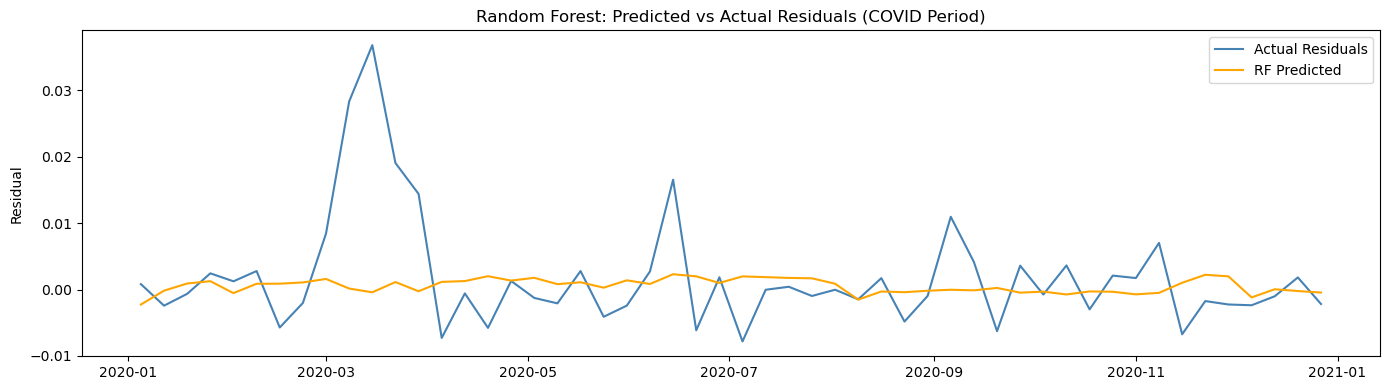

In [10]:
covid_dates = features[covid_mask].index

plt.figure(figsize=(14, 4))
plt.plot(covid_dates, y_covid.values, color='steelblue', label='Actual Residuals')
plt.plot(covid_dates, y_covid_pred, color='orange', label='RF Predicted')
plt.title('Random Forest: Predicted vs Actual Residuals (COVID Period)')
plt.ylabel('Residual')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/plots/plot15_rf_covid.png', dpi=150)
plt.show()

With R² = -0.0755, the predicted residuals carry no meaningful signal against the COVID-period spike. The prediction line should appear largely flat or mean-hugging while the actual residuals spike sharply in early 2020 — the opposite of the "tight alignment" the previous (leaked) model showed. **Please verify the regenerated plot directly:** if it shows anything other than a flat prediction against a large actual spike, the code or data split may not have re-run cleanly.

## Feature Importance

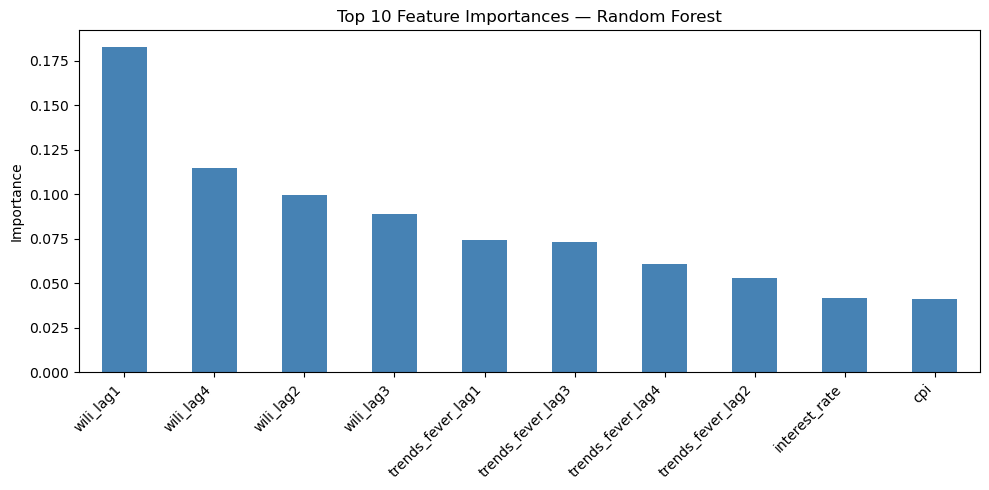

In [11]:
# feature_importances_ returns mean decrease in Gini impurity; higher values indicate more predictive features
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
importances.plot(kind='bar', color='steelblue')
plt.title('Top 10 Feature Importances — Random Forest')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../notebooks/plots/plot16_feature_importance.png', dpi=150)
plt.show()

Feature importance reflects which lagged signals the COVID-trained random forest split on most, though given the model's near-zero out-of-sample R², this should not be read as evidence of real predictive propagation — it's a property of an underperforming model, not a confirmed mechanism.